In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [17]:
A_lista = [[0.3,0,0.1],
     [0.05,1,0.2],
     [0.1, 0.15, 0.1]]

A = np.array(A_lista)
A

array([[0.3 , 0.  , 0.1 ],
       [0.05, 1.  , 0.2 ],
       [0.1 , 0.15, 0.1 ]])

In [18]:
#Consigna 1

def calcular_Leontief(A):
    tamaño = A.shape[0]
    I = np.eye(tamaño)
    return np.linalg.inv(I-A)

In [19]:
#Consigna 2
L = calcular_Leontief(A)
d = np.array([100,100,300]).reshape(3,1)

p = np.dot(L,d)
L

array([[  1.37931034,  -0.68965517,   0.        ],
       [ -2.98850575, -28.50574713,  -6.66666667],
       [ -0.34482759,  -4.82758621,  -0.        ]])

In [20]:
p
#Nos da negativo debido a que no alcanza la cantidad de producto para producirse a si mismo y alcanzar para producir a los demás debido al coeficiente = 1.
#El radio espectral tiene que ser menor a 1, mide la interrelacion y combinaciones.

array([[   68.96551724],
       [-5149.42528736],
       [ -517.24137931]])

In [21]:
#Consigna 3
def deltaProduccion(L, delta_d):
    return np.dot(L,delta_d)

In [22]:
shock = np.array([0,0,1]).reshape(3,1)
produ = deltaProduccion(L, shock)
produ

array([[ 0.        ],
       [-6.66666667],
       [ 0.        ]])

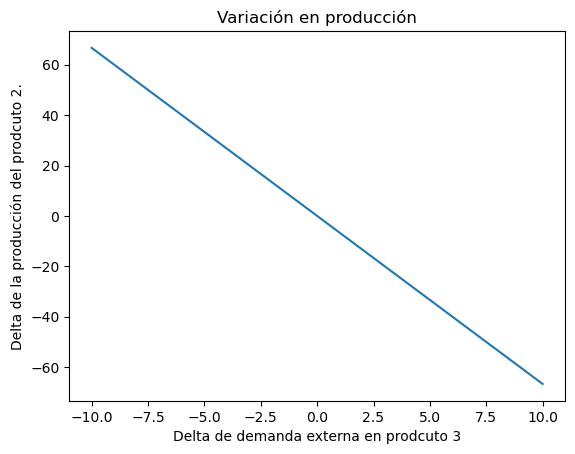

In [23]:
#Consigna 3 bis
lista_resultados = []
for i in range(-10,11,2):
    v = deltaProduccion(L,np.array([0,0,i]).reshape(3,1))
    lista_resultados.append(v[1,0])

plt.plot(range(-10,11,2),lista_resultados)
# Título general
plt.title("Variación en producción")

# Títulos de ejes
plt.xlabel("Delta de demanda externa en prodcuto 3")
plt.ylabel("Delta de la producción del prodcuto 2.")
plt.show()

In [24]:
#Coeficientes Técnicos
#Consignas 4

def calcularCoeficientes(Z,totales):
    P = np.diag(totales)
    return Z @ np.linalg.inv(P)

In [25]:
#Consigna 5
totales = [1000, 500, 1000]
Z = np.array([[350, 0, 0],
             [50, 250, 150],
             [200, 150, 550]])

A_coef = calcularCoeficientes(Z, totales)
A_coef

array([[0.35, 0.  , 0.  ],
       [0.05, 0.5 , 0.15],
       [0.2 , 0.3 , 0.55]])

<Axes: >

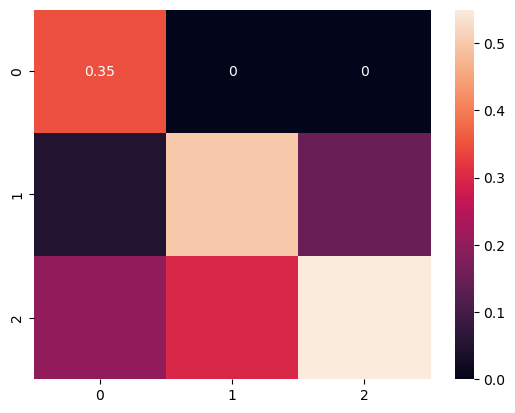

In [26]:
#Consigna 5 bis
L_coef = calcular_Leontief(A_coef)

sns.heatmap(A_coef, annot=True)

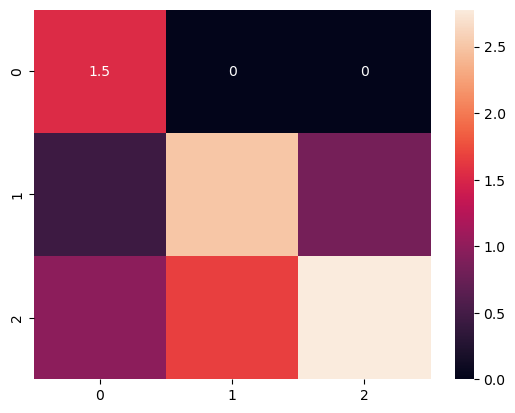

In [27]:
sns.heatmap(L_coef, annot=True)
plt.show()

In [37]:
#Matrices Regionales
#Consigna 6

def calcularLeontiefInterregional(Arr, Ars, Ass, Asr):
    n_r = Arr.shape[0] #Obtenemos el tamaño de las matrices de flujo de cada región. Las cuales son cuadradas.
    n_s = Ass.shape[0]
    Ir = np.eye(n_r) #Construimos las matrices identidades para cada región.
    Is = np.eye(n_s)
    
    return np.linalg.inv(Ir - Arr - Ars@np.linalg.inv(Is-Ass)@Asr)


In [42]:
#Consigna 7
#Primero leemos el archivo de excel para poder construir el dataframe completo con la información.

data = pd.read_excel('matrizlatina2011_compressed_0.xlsx', sheet_name='LAC_IOT_2011')

In [59]:
#Obtenemos el nombre de las columnas para poder guiarnos
columnas = data.columns.to_list()

In [75]:
#Vamos a crear las 4 matrices de flujo, siendo Argentina la P1 y Brasil la P2. Armamos Z_11, Z_12, Z_21, Z_22.

#Empezamos por Z_11. Que es la región de Argentina consigo misma.

df_Z11 = data.iloc[:40,0:43] #Dataframe de los sectores de Argentina. Incluye las columnas de ISO y Descripción del Sector.
Z_11 = np.array(df_Z11.iloc[:,3:]) #Creamos la matriz sin tener en cuenta las columnas que poseen detalles y no números.


In [79]:
#Pasamos Z_12. Que es la región de Argentina junto con Brasil. Argtina en las filas y Brasil en las columnas.

df_Z12 = pd.concat([data.iloc[:40, :3], data.iloc[:40, 43:83]], axis=1) #Dataframe de los sectores de Argentina y Brasil. Incluye las columnas de ISO y Descripción del Sector.
Z_12 = np.array(df_Z12.iloc[:,3:]) #Creamos la matriz sin tener en cuenta las columnas que poseen detalles y no números.

In [84]:
#Ahora lo que vamos a hacer es calcular las matrices para cuando Brasil se encuentra en las filas. Z_21 y Z_22.
df_Z21 = data.iloc[40:80,0:43] #Dataframe de los flujos de Brasil y Argentina que incluye descripciones.
Z_21 = np.array(df_Z21.iloc[:,3:]) 

In [88]:
#Y finalizamos con el cálculo de Z_22 con los flujos regionales de Brasil.

df_Z22 = pd.concat([data.iloc[40:80, :3], data.iloc[40:80, 43:83]], axis=1) #Creamos el dataframe
Z_22 = np.array(df_Z22.iloc[:,3:])

In [92]:
#Ademas lo que necesitamos para poder continuar es calcular una lista con todos los Totales de cada país. Seria la última columna (Output) para cada país. P1 y P2.

P1 = data.iloc[:40,-1]
P2 = data.iloc[40:80,-1]

In [94]:
#Ahora lo que hacemos es realizar las consignas porque ya tenemos todo para hacerlas

In [195]:
#1) Calcular la matriz insumo producto para cada país

A_11 = calcularCoeficientes(Z_11, P1)
A_12 = calcularCoeficientes(Z_12, P2)
A_21 = calcularCoeficientes(Z_21, P1)
A_22 = calcularCoeficientes(Z_22, P2)

In [113]:
#Buscamos el gráfico para poder mostrar la relación entre los paises.

inter_A_12 = A_12.sum(axis=1)
inter_A_21 = A_21.sum(axis=1)

nombre_sector = data["Sector"][0:40]

df_inter_top10 = pd.DataFrame({
    "Sector": nombre_sector.values,
    "Arg - Bra": inter_A_12,
    "Bra - Arg": inter_A_21,
    "Total":inter_A_12 + inter_A_21
}).nlargest(10, "Total")

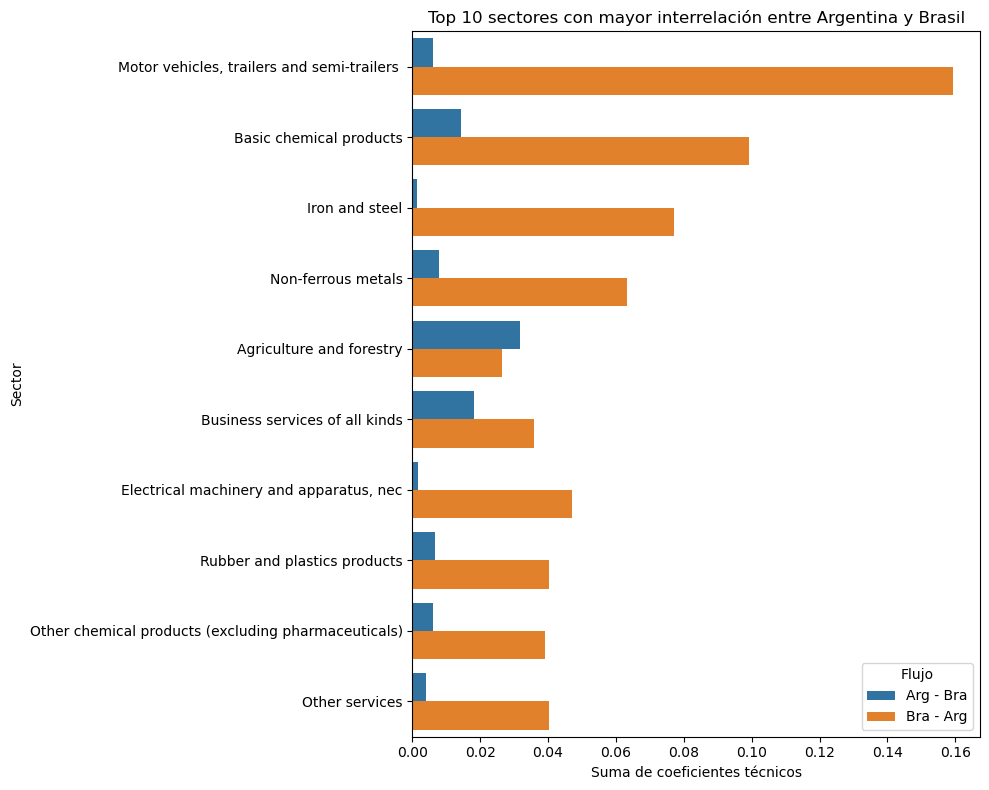

In [116]:
df_melted = df_inter_top10.melt(id_vars='Sector', value_vars=['Arg - Bra', 'Bra - Arg'], 
                                 var_name='Flujo', value_name='Interrelacion')

plt.figure(figsize=(10, 8))
sns.barplot(data=df_melted, y='Sector', x='Interrelacion', hue='Flujo', orient='h')
plt.title('Top 10 sectores con mayor interrelación entre Argentina y Brasil')
plt.xlabel('Suma de coeficientes técnicos')
plt.ylabel('Sector')
plt.tight_layout()
plt.show()

In [129]:
#Simular un shock negativo sobre el sector s05 del 10 % del total del sector, y un shock positivo del 3.3 % del total de cada uno de los siguientes sectores: s06, s07 y s08. Todos estos shocks se producen en el país P1.
shock_P1 = [0]*40
shock_P1[4] = P1[4] * -0.1; shock_P1[5:8] = [P1[5]*0.033, P1[6]*0.033, P1[7]*0.033]

In [131]:
#Simulamos como se modifica la producción en el modelo simple

produ_delta_P1 = deltaProduccion(calcular_Leontief(A_11), shock_P1)

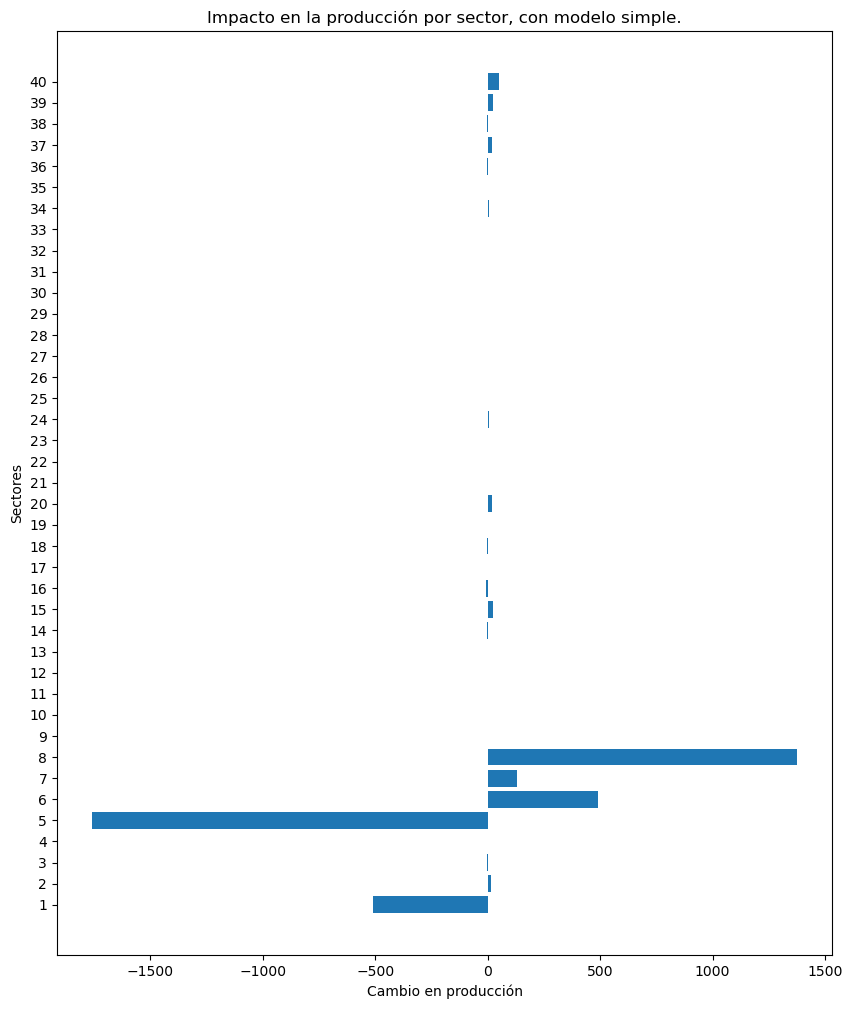

In [143]:
plt.figure(figsize=(10, 12))  # ancho, alto

plt.barh(range(1,41), produ_delta_P1)

plt.yticks(range(1,41))  # mostrar todas las etiquetas

plt.xlabel("Cambio en producción")
plt.ylabel("Sectores")
plt.title("Impacto en la producción por sector, con modelo simple.")

plt.show()

In [148]:
#Ahora lo que hacemos es simular el shock pero en el modelo de 2 regiones.
L_inter = calcularLeontiefInterregional(A_11, A_12, A_22, A_21)
produ_delta_P1_inter = deltaProduccion(L_inter, shock_P1)

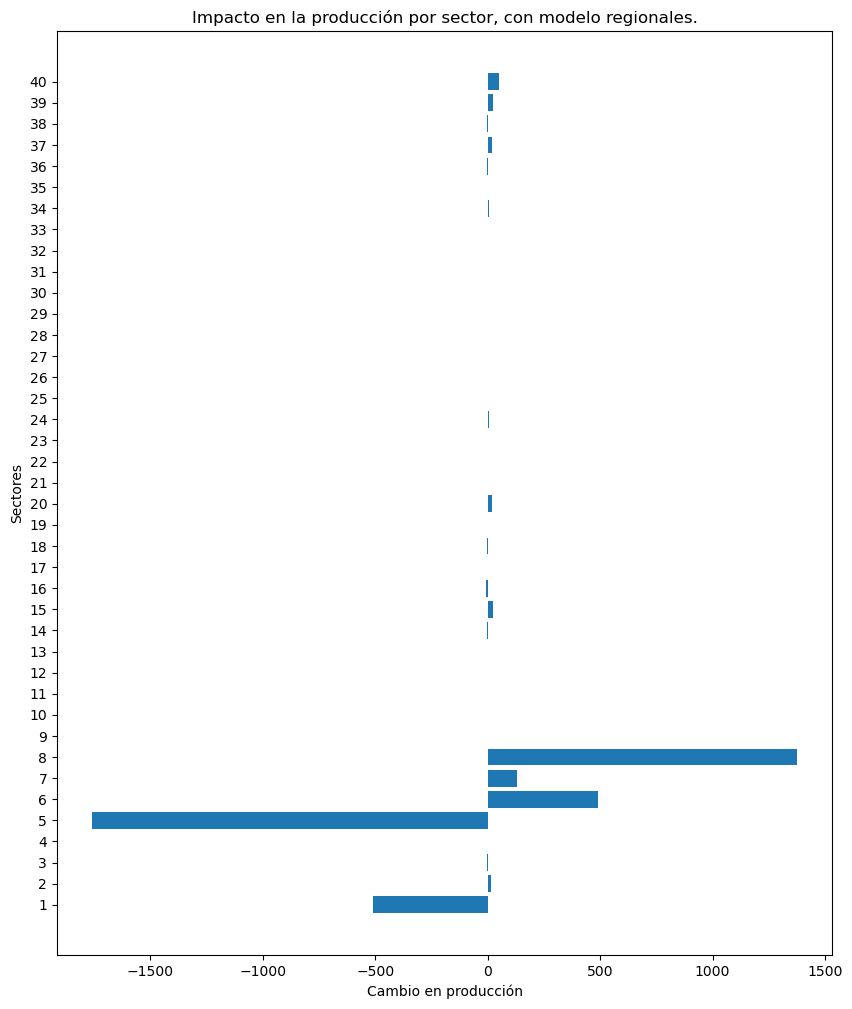

In [149]:
plt.figure(figsize=(10, 12))  # ancho, alto

plt.barh(range(1,41), produ_delta_P1_inter)

plt.yticks(range(1,41))  # mostrar todas las etiquetas

plt.xlabel("Cambio en producción")
plt.ylabel("Sectores")
plt.title("Impacto en la producción por sector, con modelo regionales.")

plt.show()

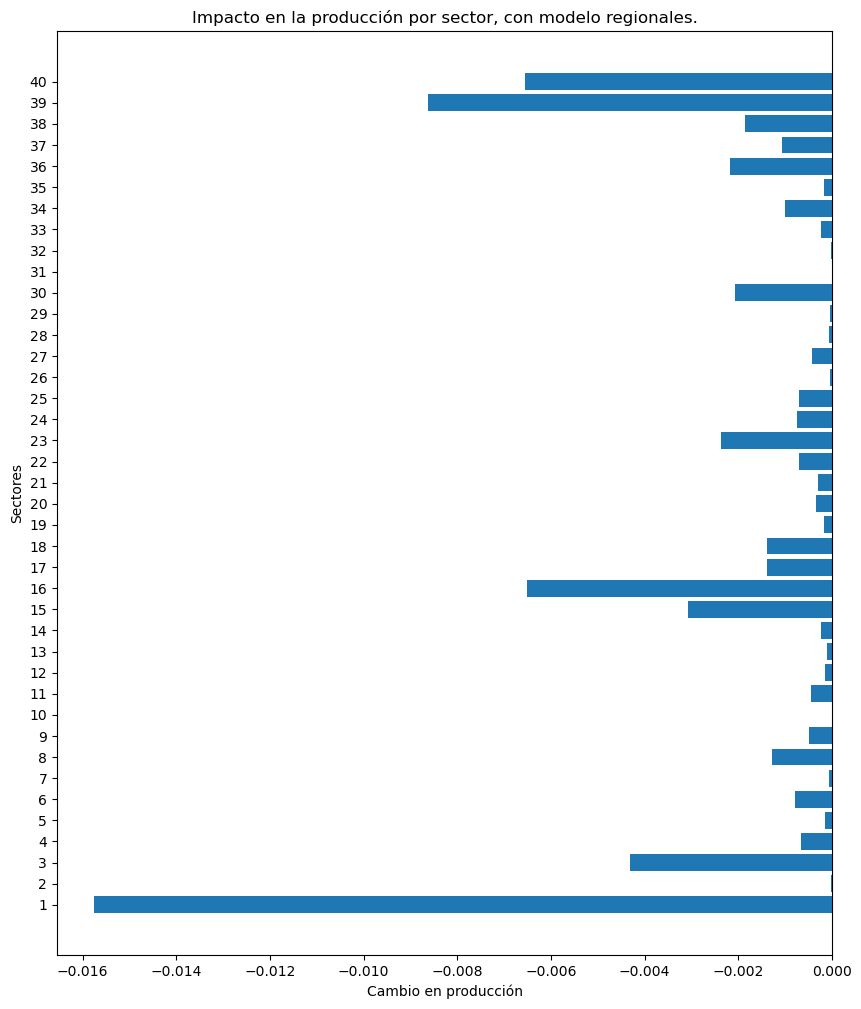

In [151]:
var_delta = produ_delta_P1 - produ_delta_P1_inter
plt.figure(figsize=(10, 12))  # ancho, alto

plt.barh(range(1,41), var_delta)

plt.yticks(range(1,41))  # mostrar todas las etiquetas

plt.xlabel("Cambio en producción")
plt.ylabel("Sectores")
plt.title("Impacto en la producción por sector, con modelo regionales.")

plt.show()


In [171]:
#Hacemos el 7bis

var_shock_7bis = np.arange(0.02,0.11,0.02).tolist()

lista_vectores_shocks = []
for i in var_shock_7bis:
    v = [0]*40
    v[4] = P1[4] * -i; v[5:8] = [P1[5]*i, P1[6]*i, P1[7]*i]
    lista_vectores_shocks.append(v)


In [ ]:
lista_variaciones = []

for i in lista_vectores_shocks:
    d_p = deltaProduccion(calcular_Leontief(A_11), i)
    var = d_p/P1
    lista_variaciones.append(var)

In [182]:
lista_variaciones_inter = []

for i in lista_vectores_shocks:
    d_p = deltaProduccion(L_inter, i)
    var = d_p/P1
    lista_variaciones_inter.append(var)

In [189]:
#Calcular la variación total de la producción de P1 y P2 para cada modelo.

#Calculamos primero, La variacion en P1 con el modelo simple.

var_nominal_P1_simple = []

for i in var_shock_7bis:
    var = deltaProduccion(calcular_Leontief(A_11), i).sum()
    var_nominal_P1_simple.append(var)
    
#La variación de P2 en el modelo simple es cero porque no estan relacionadas las regiones.

In [190]:
#Calcular la variación total de la producción de P1 y P2 para cada modelo.

#Calculamos segundo, La variacion en P2 con el modelo interegional.

var_nominal_P1_inter = []

for i in var_shock_7bis:
    var = deltaProduccion(L_inter, i).sum()
    var_nominal_P1_inter.append(var)
    
#

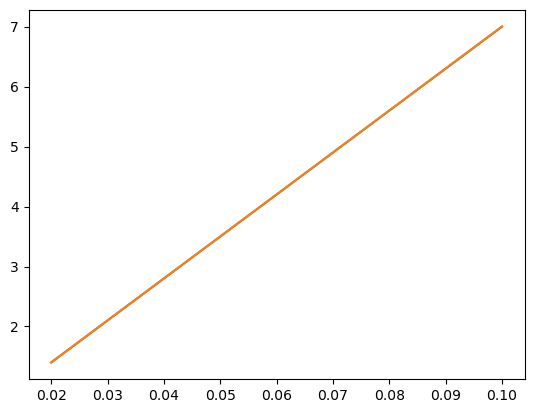

In [192]:
plt.plot(var_shock_7bis,var_nominal_P1_simple)
plt.plot(var_shock_7bis,var_nominal_P1_inter)

In [193]:
calcular_Leontief(A_11)

array([[1.19693967e+00, 2.13699833e-02, 5.57398960e-03, ...,
        3.98044478e-03, 6.28469731e-03, 2.20497561e-02],
       [6.71017676e-04, 1.00020232e+00, 1.48942292e-04, ...,
        1.27591866e-04, 1.44380086e-04, 9.35252256e-04],
       [1.59849210e-02, 2.49178610e-02, 1.10901134e+00, ...,
        3.38609983e-03, 4.23030065e-03, 5.31477233e-03],
       ...,
       [1.69114681e-02, 2.24760193e-02, 2.39082864e-02, ...,
        1.11070897e+00, 2.10067544e-02, 2.24354828e-02],
       [2.44158795e-02, 5.62430146e-02, 5.95900068e-02, ...,
        1.19737296e-01, 1.09853990e+00, 6.08453793e-02],
       [1.29107113e-01, 1.07668664e-01, 1.18529421e-01, ...,
        1.32755960e-01, 1.40637294e-01, 1.13724895e+00]])

In [194]:
calcularLeontiefInterregional(A_11, A_12, A_22, A_21)

array([[1.19695835e+00, 2.13780916e-02, 5.59500419e-03, ...,
        3.98714603e-03, 6.29602519e-03, 2.20593159e-02],
       [6.71073346e-04, 1.00020235e+00, 1.49013351e-04, ...,
        1.27613801e-04, 1.44413375e-04, 9.35278892e-04],
       [1.60087548e-02, 2.49321878e-02, 1.10905326e+00, ...,
        3.39230250e-03, 4.24270091e-03, 5.32383555e-03],
       ...,
       [1.69161817e-02, 2.24795165e-02, 2.39192068e-02, ...,
        1.11071180e+00, 2.10106268e-02, 2.24382659e-02],
       [2.44376000e-02, 5.62610253e-02, 5.96509078e-02, ...,
        1.19750346e-01, 1.09855903e+00, 6.08585619e-02],
       [1.29129696e-01, 1.07683825e-01, 1.18570900e-01, ...,
        1.32767393e-01, 1.40654053e-01, 1.13726164e+00]])